# Regression at Scale: KRR, Preconditioned KRR, Falkon, EigenPro and Random Features

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/regression_at_scale.ipynb)

kernellib has several routes to the same kernel ridge regression estimate, and they scale very differently with the number of training points $N$. This notebook runs them side by side on one synthetic problem whose optimal test error is known, and reports accuracy, wall-clock time and memory as $N$ grows, so that you can pick a solver and set its knobs.

**What you'll learn:**

1. How dense `KRR`, `KRR` with conjugate gradients, `KRR` with a Nyström or RPCholesky preconditioner, `Falkon`, `EigenPro` and ridge on random Fourier features compare in accuracy and time
2. Why plain CG needs more and more iterations as $N$ grows, and how a low-rank preconditioner fixes it
3. How many inducing points and CG iterations Falkon needs, and how many epochs EigenPro needs
4. How to choose the ridge $\lambda$, and what happens when it is too small
5. Which method to use for which $N$

## Background

Every method below estimates $f(x) = k(x, X)\,\alpha$ from $N$ noisy observations. They differ in which linear system they solve and how.

- **`KRR`, dense.** Solves $(K + \lambda N I)\alpha = y$ by Cholesky: $O(N^3)$ time and $O(N^2)$ memory.
- **`KRR` with CG** (`solver=gx.CGSolver(...)`). Conjugate gradients on the same system costs $O(N^2)$ per iteration, and needs $O(\sqrt\kappa)$ iterations with $\kappa = (\lambda_1 + \lambda N)/\lambda N$. With `implicit=True` the kernel matrix is never stored, so memory is $O(N)$.
- **Preconditioned `KRR`** (`preconditioner="nystrom"` or `"rpcholesky"`). A rank-$r$ approximation of $K$ preconditions CG {cite:p}`frangella2023nystrompcg,diaz2023robust`; once $r$ is near the effective dimension $d_{\mathrm{eff}} = \sum_i \lambda_i / (\lambda_i + \lambda N)$, the condition number is $O(1)$. It adds $O(Nr)$ memory.
- **`Falkon`** {cite:p}`rudi2017falkon`. Nyström KRR on $M$ centres, $(K_{nm}^\top K_{nm} + \lambda N K_{mm})\alpha = K_{nm}^\top y$, solved by CG with a preconditioner built from two $M \times M$ Choleskys: $O(NMT + M^3)$ time for $T$ iterations. $M \sim \sqrt N$ (up to logarithmic factors) suffices for the optimal statistical rate.
- **`EigenPro`** {cite:p}`ma2017eigenpro`. Mini-batch SGD on $K\alpha = y$ with the top `n_components` eigendirections damped, so the largest stable step grows from about $2/\lambda_1$ to about $2/\lambda_{q+1}$. There is no ridge: the number of epochs is the regulariser. Each epoch costs $O(N^2)$ kernel evaluations.
- **Ridge on random Fourier features** {cite:p}`rahimi2007rff`. With $F$ frequencies the feature matrix $\Phi$ has $2F$ columns, and $(\Phi^\top\Phi + \lambda N I) w = \Phi^\top y$ costs $O(NF^2 + F^3)$.

The ridge is scaled by $N$ in all of them, so one $\lambda$ means the same thing for `KRR`, `Falkon` and the random-feature ridge.

## The methods in detail

This section writes out what each estimator solves, how kernellib solves it, what it costs, and what can go wrong numerically. Throughout, $X$ holds $N$ training inputs, $K = k(X, X)$ is the $N \times N$ kernel matrix with eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge 0$, and $\lambda$ (`regularization`) is the ridge. kernellib scales the ridge by $N$ everywhere, as {cite:t}`rudi2017falkon` do, so the shift that actually enters the linear systems is $\lambda N$.

### Kernel ridge regression and conjugate gradients

`KRR` minimises

$$\frac1N \lVert y - K\alpha \rVert^2 + \lambda\, \alpha^\top K \alpha \quad\Longrightarrow\quad (K + \lambda N I)\,\alpha = y, \qquad f(x) = k(x, X)\,\alpha .$$

With the default `gx.DenseSolver` the system is factorised by Cholesky: $O(N^3)$ time and $O(N^2)$ memory, and the answer is exact to rounding.

Conjugate gradients (`solver=gx.CGSolver(...)`) touch $K + \lambda N I$ only through matrix-vector products, $O(N^2)$ each. With `implicit=True` the products are recomputed from the kernel, so memory is $O(N)$. After $t$ steps the error in the energy norm satisfies the classical bound

$$\frac{\lVert \alpha_t - \alpha \rVert_{K + \lambda N I}}{\lVert \alpha_0 - \alpha \rVert_{K + \lambda N I}} \le 2 \left( \frac{\sqrt\kappa - 1}{\sqrt\kappa + 1} \right)^{t}, \qquad \kappa = \frac{\lambda_1 + \lambda N}{\lambda_{N} + \lambda N} \le \frac{\lambda_1 + \lambda N}{\lambda N} \approx \frac{\lambda_1}{\lambda N},$$

so $t = O(\sqrt\kappa \log(1/\epsilon))$ steps reach relative accuracy $\epsilon$. This is why plain CG stalls. The top eigenvalue is at least the Rayleigh quotient of the constant vector, $\lambda_1 \ge \mathbf 1^\top K \mathbf 1 / N = N \bar k$ with $\bar k$ the mean kernel value, so at a fixed shift $\lambda N$ the condition number grows linearly in $N$; and shrinking $\lambda$ at fixed $N$ grows it too. Both effects are measured below.

```text
CG for (K + λN I) α = y                       # one matvec with K per step
α ← 0;  r ← y;  p ← r
repeat until ‖r‖ ≤ rtol·‖y‖ + atol or max_steps:
    q ← K p + λN p
    a ← (rᵀr) / (pᵀq)
    α ← α + a p;   r_new ← r − a q
    p ← r_new + (r_newᵀ r_new / rᵀr) p;   r ← r_new
```

**Numerics.** This notebook runs in float64 (`jax_enable_x64`). In float32 (machine epsilon $\approx 1.2 \times 10^{-7}$) a shift $\lambda N$ below roughly $\epsilon\, \lambda_1$ is lost in rounding, and both Cholesky and CG can fail; keep the shift well above it or work in float64. `KRR` warns when $\lambda < \epsilon \max_i K_{ii}$, and checks the true residual of every CG solve, raising (or, with `throw=False`, reporting `converged=False`) when CG claims convergence on a solution whose residual is far above its tolerance. The shift is the only diagonal regularisation `KRR` adds, so there is no separate jitter. `gx.CGSolver` stops at `rtol` / `atol` (here $10^{-6}$) and, inside `KRR`, raises an error if `max_steps` is reached instead of returning a partial answer.

### Preconditioned KRR: Nyström and RPCholesky

A preconditioner replaces the system by one with the same solution and a small condition number. kernellib's two choices both approximate $K$ by a rank-$r$ Nyström approximation {cite:p}`williams2001nystrom`

$$\hat K = C\, W^{+} C^\top, \qquad P = \hat K + \lambda N I,$$

and apply $P^{-1}$ through the Woodbury identity in $O(Nr)$ per step. They differ in how they choose $C$:

- **Randomized Nyström** (`preconditioner="nystrom"`, `gx.NystromPreconditioner`; {cite:t}`frangella2023nystrompcg`). With a Gaussian test matrix $\Omega \in \mathbb R^{N \times r}$, $C = K\Omega$ and $W = \Omega^\top K \Omega$, computed stably as an eigendecomposition $\hat K = U \hat\Lambda U^\top$. The inverse it applies is
  $$P^{-1} v = (\hat\lambda_r + \lambda N)\, U (\hat\Lambda + \lambda N I)^{-1} U^\top v + (I - U U^\top) v .$$
  On the range of $U$ the preconditioned operator is close to $\hat\lambda_r + \lambda N$, and on its complement it is $K + \lambda N I$ itself, so
  $$\kappa\bigl(P^{-1/2} (K + \lambda N I) P^{-1/2}\bigr) \le \frac{\hat\lambda_r + \lambda N + \lVert K - \hat K \rVert}{\lambda N}.$$
  Frangella, Tropp and Udell show that with $r$ of order the effective dimension $d_{\mathrm{eff}}(\lambda N) = \sum_i \lambda_i / (\lambda_i + \lambda N)$ (they suggest $r = 2\lceil 1.5\, d_{\mathrm{eff}} \rceil + 1$) the expected condition number is bounded by a constant, below 28, whatever $N$. Building it costs $r$ products with $K$, done as one matrix-matrix product.
- **Randomly pivoted Cholesky** (`preconditioner="rpcholesky"`, `gx.PartialCholeskyPreconditioner` with random pivoting; {cite:t}`chen2023rpcholesky`, {cite:t}`diaz2023robust`). $C = K_{:,S}$ and $W = K_{S,S}$ on $r$ pivots $S$, each drawn with probability proportional to the diagonal of the current residual $K - \hat K$; the result is a factor $F$ with $\hat K = F F^\top$, and
  $$P^{-1} = \frac{1}{\lambda N} \Bigl( I - F \bigl(\lambda N I + F^\top F\bigr)^{-1} F^\top \Bigr).$$
  Díaz et al. show that an RPCholesky preconditioner of rank of order $d_{\mathrm{eff}}$, up to logarithmic factors, also gives a condition number bounded by a constant with high probability. In principle it needs only $O(Nr)$ kernel evaluations; the current gaussx implementation takes each pivot column as a full product with $K$ instead (see the timings below).

```text
Preconditioned CG for (K + λN I) α = y with P ≈ K + λN I
build P once:  Nyström: Y ← K Ω;  Û Λ̂ Ûᵀ ← Nyström(Y, Ω)       (r matvecs)
               RPCholesky: F ← rp_cholesky(diag K, columns of K, r)
α ← 0;  r ← y;  z ← P⁻¹ r;  p ← z
repeat until converged:
    q ← K p + λN p
    a ← (rᵀz) / (pᵀq)
    α ← α + a p;   r_new ← r − a q;   z_new ← P⁻¹ r_new          (Woodbury, O(N r))
    p ← z_new + (r_newᵀ z_new / rᵀz) p;   r, z ← r_new, z_new
```

In kernellib, `KRR(preconditioner=...)` builds $P$ from $K$ without the shift and passes $\lambda N$ separately, so the ridge is never counted twice, and then solves with `gx.PreconditionedCGSolver` (`rtol = atol = 1e-6`, at most 1000 steps). A preconditioner needs a `key` in `fit`.

**Numerics.** The cost of a too-small rank is iterations, not accuracy: the solution is the KRR solution whatever $P$ is. RPCholesky stops pivoting once the residual diagonal falls below $N \epsilon \max_i K_{ii}$ (the numerical rank is exhausted) and pads the factor with zero columns, so a rank above the numerical rank is safe.

### Falkon

`Falkon` {cite:p}`rudi2017falkon,meanti2020falkon` restricts the KRR solution to $M$ centres $Z$ chosen from the data (`centers="uniform"` by default; any rule of `select_landmarks`), $f(x) = k(x, Z)\,\alpha$ with $\alpha \in \mathbb R^M$. Writing $K_{nm} = k(X, Z)$ and $K_{mm} = k(Z, Z)$, the objective and its normal equations are

$$\min_\alpha \frac1N \lVert K_{nm}\alpha - y \rVert^2 + \lambda\, \alpha^\top K_{mm} \alpha \quad\Longrightarrow\quad H\alpha := (K_{nm}^\top K_{nm} + \lambda N K_{mm})\,\alpha = K_{nm}^\top y .$$

This is the same $\lambda$ as in `KRR` (with $Z = X$ it is exactly KRR) and as in Rudi et al. Falkon preconditions $H$ with its Nyström approximation, $K_{nm}^\top K_{nm} \approx \frac{N}{M} K_{mm}^2$. With upper-triangular Cholesky factors

$$T^\top T = K_{mm} + \delta I, \qquad A^\top A = \tfrac1M\, T T^\top + \lambda I, \qquad B = T^{-1} A^{-1},$$

one has $B B^\top = N \bigl(\tfrac{N}{M} K_{mm}^2 + \lambda N K_{mm}\bigr)^{-1}$ (with $K_{mm}$ the jittered matrix), so $B^\top H B$ is close to a multiple of the identity. CG runs on $\beta = B^{-1}\alpha$:

$$A^{-\top} \bigl[ T^{-\top} K_{nm}^\top K_{nm} T^{-1} + \lambda N I \bigr] A^{-1} \beta = A^{-\top} T^{-\top} K_{nm}^\top y, \qquad \alpha = T^{-1} A^{-1} \beta,$$

in which $K_{mm}$ has cancelled. Each step costs one product with $K_{nm}$ and one with $K_{nm}^\top$, $O(NM)$, plus four $M \times M$ triangular solves; building the preconditioner costs $O(M^3)$. Total: $O(NMt + M^3)$ time for $t$ steps, and $O(M^2)$ memory when $K_{nm}$ is streamed (`implicit=True`, the default) or $O(NM)$ when it is stored (`implicit=False`, used here). Rudi et al. prove that $M$ of order $\sqrt N$ centres (up to logarithmic factors) and $t$ of order $\log N$ iterations achieve the optimal statistical rate of exact KRR under standard assumptions, for $O(N\sqrt N)$ total time up to logarithmic factors.

```text
Falkon.fit(X, y)                                   # kernellib, _estimators.py + _falkon.py
Z ← X[select_landmarks(kernel, X, M, method=centers)]     (Z = X if M ≥ N)
δ ← max(M · eps · max diag K_mm, tiny)                     # default jitter
T ← chol_upper(K_mm + δ I);   A ← chol_upper(T Tᵀ / M + λ I)
b ← A⁻ᵀ T⁻ᵀ K_nmᵀ y
op(β) = A⁻ᵀ ( T⁻ᵀ K_nmᵀ K_nm T⁻¹ A⁻¹ β + λN A⁻¹ β )
β ← CG(op, b, rtol = tol, atol = tol · max|b|, max_steps = max_iter)   # never raises
α ← T⁻¹ A⁻¹ β;  record n_iter and converged
predict(x) = k(x, Z) α
```

**Numerics.** The jitter $\delta = M \epsilon \max_i (K_{mm})_{ii}$ (floored at the smallest normal number) keeps the first Cholesky finite when centres nearly coincide, without changing the solution at working precision. `max_iter` is a budget, not a failure: the iterate at the budget is returned, and `converged` reports whether `tol` (a max-norm relative residual) was met. Below, Falkon never meets $10^{-6}$ in 20 steps for $\lambda N < 1$, yet its test error stops changing after about 20 steps. Too small a $\lambda$ makes the Nyström system itself ill-posed and the solution fits the noise; that, not the solver, is what goes wrong at small $\lambda N$ below.

### EigenPro

`EigenPro` {cite:p}`ma2017eigenpro,ma2019eigenpro2` fits the interpolating solution of $K\alpha = y$ by mini-batch SGD on $\frac{1}{2N}\lVert K\alpha - y \rVert^2$ in function space. There is no ridge: stopping after a few epochs is the regulariser. Plain kernel SGD with batch size $b$ is limited by the top eigenvalue of the (normalised) kernel operator: above a critical batch size its largest stable step is about $2/\lambda_1$, so the directions with small eigenvalues, which carry most of the fit, converge very slowly. EigenPro flattens the top of the spectrum. On a subsample $S$ of $m$ points it takes the top $q + 1$ eigenpairs $(\lambda_i, v_i)$ of $K_{SS}/m$, extends them to the data by Nyström, $e_i(x) = k(x, S)\, v_i / \sqrt{m \lambda_i}$, and preconditions with

$$P = I - \sum_{i=1}^{q} \Bigl(1 - \bigl(\tfrac{\lambda_{q+1}}{\lambda_i}\bigr)^{a}\Bigr)\, e_i e_i^\top ,$$

which maps eigenvalue $\lambda_i$ ($i \le q$) to $\lambda_{q+1}^{a} \lambda_i^{1 - a}$. With $a = 1$ every top eigenvalue becomes $\lambda_{q+1}$, as in Ma and Belkin's paper; kernellib's `decay` is $a$, with default $0.95$, a slightly softer correction. In coefficients, one step on a batch $B$ with residuals $g = K_{BX}\alpha - y_B$ is

$$\alpha_B \leftarrow \alpha_B - \frac{\eta}{b}\, g, \qquad \alpha_S \leftarrow \alpha_S + \frac{\eta}{b\, m}\, V D V^\top K_{SB}\, g, \qquad D_i = \frac{1 - (\lambda_{q+1}/\lambda_i)^{a}}{\lambda_i}.$$

The step size follows Ma and Belkin. With $\beta = \max_x k_P(x, x)$ the largest diagonal of the preconditioned kernel and $\lambda_P = \lambda_1 (1 - D_1 \lambda_1)$ the top eigenvalue of the preconditioned operator,

$$\eta = \begin{cases} b / \beta, & b < b^* = \beta / \lambda_P, \\ 2b / \bigl(\beta + (b - 1)\lambda_P\bigr), & b \ge b^*. \end{cases}$$

For large batches $\eta \approx 2/\lambda_P$, about $2/\lambda_{q+1}$ instead of plain SGD's $2/\lambda_1$, and the critical batch size $b^* = \beta/\lambda_P$ grows roughly by the same factor, which is what lets EigenPro 2.0 use large batches efficiently. Each step costs $O(bN)$ kernel evaluations for $K_{BX}$ plus $O(bm + mq)$ for the correction; an epoch is $O(N^2)$.

```text
EigenPro.fit(X, y)                                  # kernellib, _estimators.py + _eigenpro.py
S ← select_landmarks(kernel, X, m, method=subsample)
λ, V ← eigh(K_SS / m), descending                    # dense: see below
D_i ← (1 − (λ_{q+1}/λ_i)^a) / λ_i  for i ≤ q         (eigenvalues floored at eps)
β ← max over all x of k(x,x) − Σ_i D_i (k(x,S) V_i)² / m     # lax.scan over row chunks of 256
λ_P ← λ_1 (1 − D_1 λ_1);   η ← step size above
α ← 0
scan over epochs (one key each):
    order ← permutation(N), padded to ⌈N / b⌉ · b      # the last batch may be partial
    scan over batches B of order:
        g ← k(X_B, X) α − y_B, zero on padded rows
        α_B ← α_B − (η / b) g
        α_S ← α_S + (η / (b m)) V diag(D) Vᵀ k(X_S, X_B) g
predict(x) = k(x, X) α
```

kernellib uses a dense `eigh` of the $m \times m$ matrix rather than Lanczos on purpose: a Lanczos run of only $q + 1$ steps converges the leading eigenpairs but not the trailing one, and the tail eigenvalue $\lambda_{q+1}$ sets every correction weight, so an inaccurate one over-damps the spectrum. The matrix is already materialised, so the dense decomposition costs $O(m^3)$ once.

**Numerics.** Eigenvalues are floored at machine epsilon before the weights and the step size are formed, so a rank-deficient subsample cannot produce infinite weights. `n_components` must be below the subsample size. With too few damped directions the step is limited by a large $\lambda_P$ and progress is slow; with no ridge, running too many epochs fits the noise. Both show up in the experiment below.

### Ridge on random features

With a feature map $\phi : \mathbb R^D \to \mathbb R^F$ such that $\phi(x)^\top \phi(x') \approx k(x, x')$, such as random Fourier features {cite:p}`rahimi2007rff` (`RandomFourierFeatures`, $2F$ columns from $F$ frequencies), KRR becomes ridge regression in the primal:

$$(\Phi^\top \Phi + \lambda N I)\, w = \Phi^\top y, \qquad f(x) = \phi(x)^\top w,$$

the same $\lambda N$ convention as `KRR`. Forming $\Phi^\top \Phi$ costs $O(N F^2)$, its Cholesky $O(F^3)$, and memory is $O(NF)$ for $\Phi$, or $O(F^2)$ if $\Phi^\top \Phi$ is accumulated in batches. The approximation error of the kernel decays like $O(1/\sqrt F)$, so beyond some $N$ the feature count, not the data, limits the accuracy.

**Numerics.** The $2F \times 2F$ system is small and well conditioned for $\lambda N$ not much below the feature variance; we factorise it by Cholesky in float64. In float32 with a tiny shift, $\Phi^\top\Phi$ can be numerically singular, since $2F$ random features of a smooth kernel are close to linearly dependent.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import logging
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import os
import platform
import statistics
import time

import einx
import equinox as eqx
import gaussx as gx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import kernellib as kl


jax.config.update("jax_enable_x64", True)
notebook_start = time.perf_counter()

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,gaussx,lineax,matplotlib,kernellib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.17.1

jax       : 0.11.2
gaussx    : 0.6.1
lineax    : 0.1.1
matplotlib: 3.11.2
kernellib : 0.0.16

Compiler    : Clang 21.1.4 
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



### The machine

Wall-clock numbers mean little without the hardware, so we print the CPU model and core count, and the load average: the timings below were taken on a shared machine, and the load says how many other processes were competing for the cores. On a loaded machine, multithreaded LAPACK can be dozens of times slower than single-threaded (its threads spin waiting for each other), so this notebook was executed with `OMP_NUM_THREADS=1`. On an idle machine, leave it unset.

In [4]:
def cpu_model():
    try:
        with open("/proc/cpuinfo") as fh:
            for line in fh:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except OSError:
        pass
    return platform.processor() or platform.machine()


print(f"CPU:          {cpu_model()}")
print(f"Logical cores: {os.cpu_count()}")
print(f"JAX backend:  {jax.default_backend()}, float64 enabled")
print(f"OMP_NUM_THREADS = {os.environ.get('OMP_NUM_THREADS', 'unset')}")
print("Load average (1, 5, 15 min): {:.1f}, {:.1f}, {:.1f}".format(*os.getloadavg()))

CPU:          Intel(R) Xeon(R) Platinum 8171M CPU @ 2.60GHz
Logical cores: 16
JAX backend:  cpu, float64 enabled
OMP_NUM_THREADS = 1
Load average (1, 5, 15 min): 11.3, 15.8, 20.5


## The problem

Inputs are uniform on $[-1, 1]^8$ and the target is a smooth sum of four ridge functions plus Gaussian noise with $\sigma = 0.1$:

$$y = \tfrac12 \sum_{k=1}^{4} \sin(2\, w_k^\top x) + \varepsilon, \qquad \varepsilon \sim \mathcal N(0, \sigma^2).$$

The best possible test MSE on noisy targets is $\sigma^2$, so we report $\mathrm{MSE}/\sigma^2$, which is at least 1. To keep the score free of test-set noise we evaluate the expected noisy-target MSE exactly, as $\sigma^2$ plus the mean squared error against the noise-free $f$ on 2000 test points.

In [5]:
D, sigma = 8, 0.1
W = jax.random.normal(jax.random.PRNGKey(0), (4, D)) / jnp.sqrt(D)


def f_true(X):
    return 0.5 * einx.sum("n k -> n", jnp.sin(2.0 * einx.dot("n d, k d -> n k", X, W)))


def make_data(n, key):
    k_x, k_eps = jax.random.split(key)
    X = jax.random.uniform(k_x, (n, D), minval=-1.0, maxval=1.0)
    return X, f_true(X) + sigma * jax.random.normal(k_eps, (n,))


X_test = jax.random.uniform(jax.random.PRNGKey(1), (2000, D), minval=-1.0, maxval=1.0)
f_test = f_true(X_test)


def score(y_pred):
    """Expected test MSE on noisy targets, over sigma^2 (the floor is 1)."""
    return float((jnp.mean((y_pred - f_test) ** 2) + sigma**2) / sigma**2)


N_MAX = 16_000
X_all, y_all = make_data(N_MAX, jax.random.PRNGKey(2))
print(f"Var(y) / sigma^2 = {float(jnp.var(y_all)) / sigma**2:.1f}  (predicting 0)")

Var(y) / sigma^2 = 40.6  (predicting 0)


Training sets of every size are nested prefixes of one draw of 16 000 points, so a larger $N$ only adds data.

One RBF kernel serves every method. Its lengthscale comes from the median heuristic on a 2000-point subsample. The ridge is $\lambda = 10^{-2}/N$, so the shift $\lambda N = 10^{-2}$ is the same at every $N$; the section on choosing $\lambda$ below shows where that value comes from.

In [6]:
ell = kl.estimate_lengthscale(X_all, subsample=2000, key=jax.random.PRNGKey(3))
kernel = kl.RBF(lengthscale=ell)
LAM_N = 1e-2  # the shift lambda * N


def lam(n):
    return LAM_N / n


print(f"Median-heuristic lengthscale: {float(ell):.3f}")

Median-heuristic lengthscale: 2.259


## Timing

Each `fit` is wrapped in `equinox.filter_jit`. The first call compiles and runs; we then time three more calls with `jax.block_until_ready` and report their median, so the fit time excludes compilation. Compile time is reported separately as the first call minus the median.

In [7]:
fit_jit = eqx.filter_jit(lambda model, X, y, key: model.fit(X, y, key=key))


def timed_fit(model, X, y, key, repeats=3):
    t0 = time.perf_counter()
    fitted = jax.block_until_ready(fit_jit(model, X, y, key))
    first = time.perf_counter() - t0
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fitted = jax.block_until_ready(fit_jit(model, X, y, key))
        times.append(time.perf_counter() - t0)
    median = statistics.median(times)
    return fitted, median, max(first - median, 0.0)

Random-feature ridge is not a kernellib estimator, so we write a small one with the same `fit` / `predict` interface: a `RandomFourierFeatures` map and a closed-form solve.

In [8]:
class RFFRidge(eqx.Module):
    kernel: kl.AbstractKernel
    n_features: int = eqx.field(static=True)
    regularization: float = 1e-3
    feature_map: kl.RandomFourierFeatures | None = None
    weights: jax.Array | None = None

    def fit(self, X, y, *, key):
        fm = kl.RandomFourierFeatures(self.n_features, key).fit(self.kernel, X)
        Phi = fm(X)
        gram = einx.dot("n a, n b -> a b", Phi, Phi)
        ridge = self.regularization * X.shape[0] * jnp.eye(gram.shape[0])
        cho = jax.scipy.linalg.cho_factor(gram + ridge)
        w = jax.scipy.linalg.cho_solve(cho, einx.dot("n a, n -> a", Phi, y))
        return eqx.tree_at(
            lambda m: (m.feature_map, m.weights),
            self,
            (fm, w),
            is_leaf=lambda x: x is None,
        )

    def predict(self, X):
        return self.feature_map(X) @ self.weights

## The methods

Each method gets the largest $N$ it handles within this notebook's runtime budget on the CPU above. Past those caps we stop rather than extrapolate.

- Dense `KRR` up to $N = 4000$: one Cholesky of the $N \times N$ matrix.
- `KRR` by plain CG, and preconditioned `KRR` with rank $r = 300$, up to $N = 4000$. These fits store the kernel matrix (`implicit=False`), because at these sizes forming it once is far cheaper than recomputing it at every CG step. `implicit=True` solves the same system with the same iterations in $O(N)$ memory; a check further down confirms that it gives the same answer, and shows what it costs on this CPU.
- `EigenPro` up to $N = 8000$: 5 epochs of $O(N^2)$ kernel evaluations each.
- `Falkon` with $M = 1000$ centres (with `implicit=False`, so the $N \times M$ cross kernel is stored rather than streamed) and ridge on 512 random Fourier frequencies (1024 features) up to $N = 16\,000$.

In [9]:
R_PRECOND = 300

methods = {
    "KRR (dense)": (lambda n: kl.KRR(kernel, regularization=lam(n)), 4000),
    "KRR (CG)": (
        lambda n: kl.KRR(
            kernel,
            regularization=lam(n),
            solver=gx.CGSolver(rtol=1e-6, atol=1e-6, max_steps=2000),
        ),
        4000,
    ),
    "KRR (PCG, Nyström r=300)": (
        lambda n: kl.KRR(
            kernel,
            regularization=lam(n),
            preconditioner="nystrom",
            preconditioner_rank=R_PRECOND,
        ),
        4000,
    ),
    "KRR (PCG, RPCholesky r=300)": (
        lambda n: kl.KRR(
            kernel,
            regularization=lam(n),
            preconditioner="rpcholesky",
            preconditioner_rank=R_PRECOND,
        ),
        4000,
    ),
    "EigenPro (q=160, 5 epochs)": (
        lambda n: kl.EigenPro(
            kernel, epochs=5, batch_size=512, subsample_size=2000, n_components=160
        ),
        8000,
    ),
    "Falkon (M=1000)": (
        lambda n: kl.Falkon(
            kernel, n_inducing=1000, regularization=lam(n), implicit=False
        ),
        16_000,
    ),
    "RFF ridge (1024 features)": (
        lambda n: RFFRidge(kernel, n_features=512, regularization=lam(n)),
        16_000,
    ),
}


def peak_mb(name, n):
    """Size of the largest array each method holds, in MB (float64)."""
    elements = {
        "KRR (dense)": n * n,
        "KRR (CG)": n * n,
        "KRR (PCG, Nyström r=300)": n * n + n * R_PRECOND,
        "KRR (PCG, RPCholesky r=300)": n * n + n * R_PRECOND,
        "EigenPro (q=160, 5 epochs)": 512 * n + 2000 * 2000,
        "Falkon (M=1000)": n * min(1000, n),
        "RFF ridge (1024 features)": n * 1024,
    }[name]
    return 8 * elements / 1e6

## The sweep

In [10]:
N_values = [1000, 2000, 4000, 8000, 16_000]
results = {name: [] for name in methods}
fit_key = jax.random.PRNGKey(4)

print(f"{'method':<29} {'N':>6} {'MSE/s2':>7} {'fit s':>8} {'compile s':>9} {'MB':>7}")
for n in N_values:
    X, y = X_all[:n], y_all[:n]
    for name, (make, n_max) in methods.items():
        if n > n_max:
            continue
        model, t_fit, t_compile = timed_fit(make(n), X, y, fit_key)
        s = score(model.predict(X_test))
        mb = peak_mb(name, n)
        results[name].append((n, s, t_fit, t_compile))
        print(f"{name:<29} {n:>6} {s:>7.3f} {t_fit:>8.2f} {t_compile:>9.2f} {mb:>7.0f}")

method                             N  MSE/s2    fit s compile s      MB


KRR (dense)                     1000   1.634     0.03      0.62       8


KRR (CG)                        1000   1.634     0.05      0.55       8


KRR (PCG, Nyström r=300)        1000   1.634     0.19      1.43      10


KRR (PCG, RPCholesky r=300)     1000   1.634     0.21      1.07      10


...

EigenPro (q=160, 5 epochs)      8000   1.310     7.56      3.60      65


Falkon (M=1000)                 8000   1.229     0.51      1.36      64


RFF ridge (1024 features)       8000   1.272     0.33      0.98      66


Falkon (M=1000)                16000   1.190     0.68      1.04     128


RFF ridge (1024 features)      16000   1.236     0.60      0.91     131


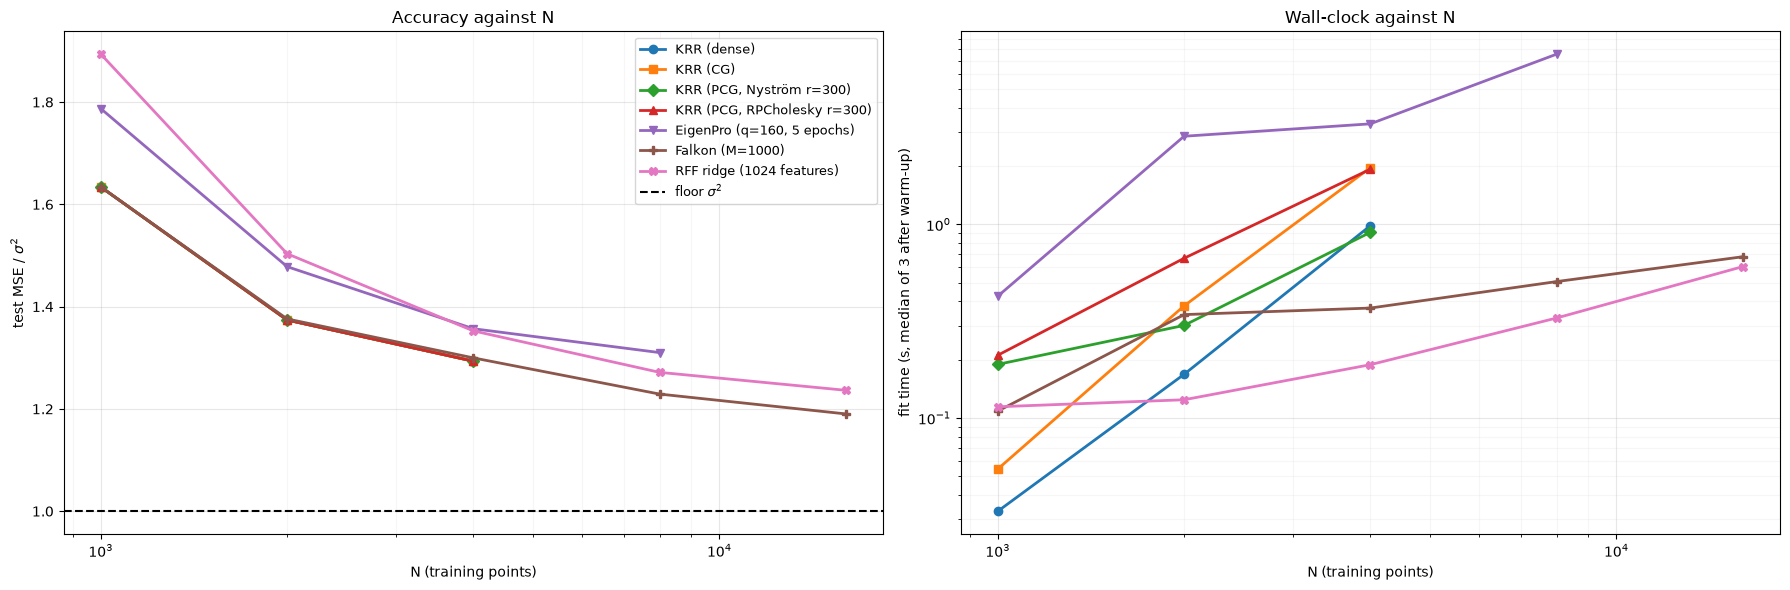

In [11]:
markers = ["o", "s", "D", "^", "v", "P", "X"]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for (name, rows), marker in zip(results.items(), markers, strict=True):
    ns = [r[0] for r in rows]
    axes[0].semilogx(ns, [r[1] for r in rows], marker=marker, lw=2, label=name)
    axes[1].loglog(ns, [r[2] for r in rows], marker=marker, lw=2, label=name)
axes[0].axhline(1.0, color="k", ls="--", lw=1.5, label=r"floor $\sigma^2$")
axes[0].set_ylabel(r"test MSE / $\sigma^2$")
axes[0].set_title("Accuracy against N")
axes[1].set_ylabel("fit time (s, median of 3 after warm-up)")
axes[1].set_title("Wall-clock against N")
for ax in axes:
    ax.set_xlabel("N (training points)")
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

**Accuracy.** The four exact-KRR routes (dense, plain CG and both preconditioned CGs) solve the same system to tolerance, and give the same test error at every $N$: 1.634, 1.374 and 1.293 times $\sigma^2$ at $N$ = 1000, 2000 and 4000. Falkon with $M = 1000$ centres matches them to within 0.01 (1.376 against 1.374 at $N = 2000$, 1.300 against 1.293 at 4000), and keeps improving as $N$ grows past what exact KRR handles here, to 1.190 at $N = 16\,000$, the best score in the sweep. Ridge on 1024 random features is 3 to 4 percent behind Falkon at 8000 and 16 000 (1.272 against 1.229, 1.236 against 1.190). EigenPro after 5 epochs trails both (1.310 at $N = 8000$). Every method improves with $N$ and none reaches the floor of 1 at these sizes.

**Time.** At $N = 4000$, the largest size every method ran at, the fits took: dense KRR 0.98 s, plain CG 1.96 s, Nyström-preconditioned CG 0.91 s, RPCholesky-preconditioned CG 1.92 s, EigenPro 3.30 s, Falkon 0.37 s and random-feature ridge 0.19 s. Dense KRR and plain CG grew fastest, from 0.03 s to 0.98 s and from 0.05 s to 1.96 s between $N = 1000$ and 4000; Falkon and random-feature ridge stayed under 0.7 s all the way to $N = 16\,000$ (0.68 s and 0.60 s). EigenPro is the slowest at every $N$ (7.56 s at 8000), since each epoch evaluates the full $N \times N$ kernel in batches. Compile times, reported separately, were mostly between 0.4 and 2 s per method and size (one is 3.6 s, and one is clipped to zero); they are noisy, being the difference of two timings on a busy machine.

## Why plain CG stalls, and what the preconditioner buys

`KRR` does not report how many CG steps it took, so we count them by solving the same system, $(K + \lambda N I)\alpha = y$, with lineax's CG directly (`throw=False` returns the step count instead of raising when the budget runs out). With $\lambda N$ fixed, the top eigenvalue of $K$ grows like $N$ while the shift does not, so the condition number grows with $N$, and so does the effective dimension the preconditioner has to capture. Kernel matrices are stored here, which changes the cost per step but not the number of steps.

In [12]:
cg = lx.CG(rtol=1e-6, atol=1e-6, max_steps=3000)


@eqx.filter_jit
def cg_steps(X, y, shift, precond, key):
    K = kl.to_operator(kernel, X)
    A = kl.to_operator(kernel, X, noise=shift)
    options = {}
    if precond == "nystrom":
        P = gx.NystromPreconditioner.from_operator(K, R_PRECOND, shift=shift, key=key)
        options["preconditioner"] = P.as_operator(A)
    elif precond == "rpcholesky":
        P = gx.PartialCholeskyPreconditioner.from_operator(
            K, R_PRECOND, shift=shift, pivoting="random", key=key
        )
        options["preconditioner"] = P.as_operator(A)
    sol = lx.linear_solve(A, y, cg, options=options, throw=False)
    return sol.stats["num_steps"]


N_cg = [500, 1000, 2000, 4000]
steps = {"none": [], "nystrom": [], "rpcholesky": []}
print(f"{'N':>6} {'plain CG':>9} {'Nyström':>8} {'RPChol':>7}")
for n in N_cg:
    X, y = X_all[:n], y_all[:n]
    for p in steps:
        steps[p].append(int(cg_steps(X, y, LAM_N, p, jax.random.PRNGKey(5))))
    print(
        f"{n:>6} {steps['none'][-1]:>9} {steps['nystrom'][-1]:>8} "
        f"{steps['rpcholesky'][-1]:>7}"
    )

     N  plain CG  Nyström  RPChol


   500       136        8       8


  1000       185       11      11


  2000       224       14      13


  4000       281       18      17


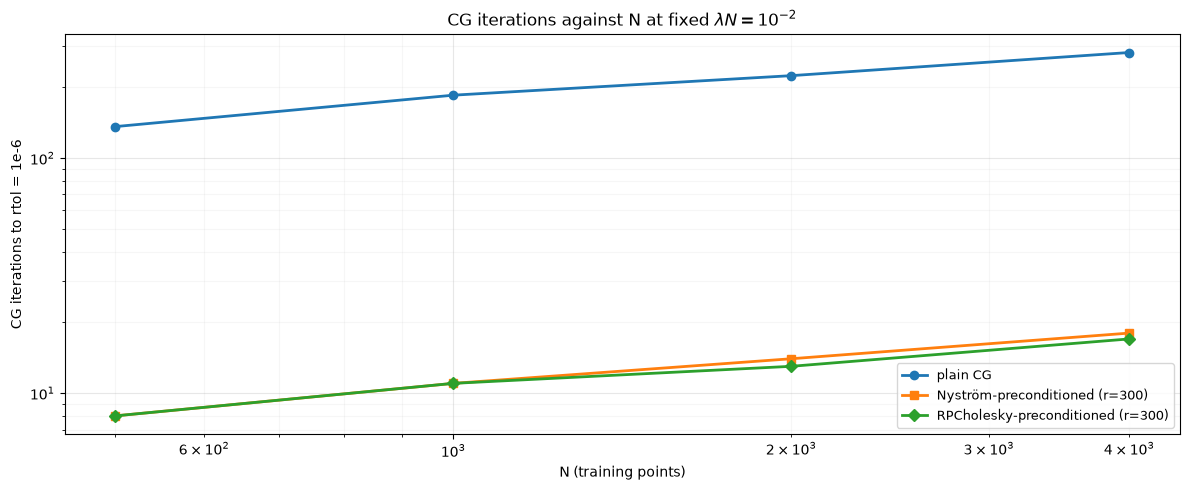

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
labels = {
    "none": "plain CG",
    "nystrom": f"Nyström-preconditioned (r={R_PRECOND})",
    "rpcholesky": f"RPCholesky-preconditioned (r={R_PRECOND})",
}
for (p, counts), marker in zip(steps.items(), ["o", "s", "D"], strict=True):
    ax.loglog(N_cg, counts, marker=marker, lw=2, label=labels[p])
ax.set_xlabel("N (training points)")
ax.set_ylabel("CG iterations to rtol = 1e-6")
ax.set_title(r"CG iterations against N at fixed $\lambda N = 10^{-2}$")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
plt.tight_layout()
plt.show()

Plain CG needs 136 iterations at $N = 500$ and 281 at $N = 4000$: about twice as many for eight times the data, on top of each iteration costing $O(N^2)$. That is why plain CG was the slowest exact route in the sweep (1.96 s at $N = 4000$, twice dense KRR). With a rank-300 preconditioner of either kind, 8 to 18 iterations suffice over the same range, 15 to 17 times fewer. The preconditioned count still rises, from 8 to 18, because at fixed $\lambda N$ the effective dimension grows with $N$ while the rank stays at 300.

The two preconditioners need almost the same number of steps (17 and 18 at $N = 4000$), yet the RPCholesky fit was about twice as slow in the sweep (1.92 s against 0.91 s). Both cost $r$ products with $K$ to build: in gaussx 0.6.1, `PartialCholeskyPreconditioner.from_operator` extracts each pivot column with a full matrix-vector product, one after another, while `NystromPreconditioner` applies $K$ to all $r$ sketch vectors in one matrix-matrix product.

### The same fit, matrix-free

With `implicit=True` the kernel matrix is never formed: every matrix-vector product recomputes $K v$ from the kernel, in $O(N)$ memory. We fit the RPCholesky-preconditioned `KRR` both ways and compare predictions and time. This check runs at $N = 1000$ with rank $r = 100$, because building the preconditioner matrix-free turned out to be expensive, as the timings show.

In [14]:
n = 1000
X, y = X_all[:n], y_all[:n]
pcg_kwargs = dict(
    regularization=lam(n), preconditioner="rpcholesky", preconditioner_rank=100
)
stored, t_stored, _ = timed_fit(kl.KRR(kernel, **pcg_kwargs), X, y, fit_key)
free, t_free, _ = timed_fit(kl.KRR(kernel, implicit=True, **pcg_kwargs), X, y, fit_key)
gap = float(jnp.max(jnp.abs(stored.predict(X_test) - free.predict(X_test))))
matvec = eqx.filter_jit(lambda X, v: kl.to_operator(kernel, X, implicit=True).mv(v))
jax.block_until_ready(matvec(X, y))
times = []
for _ in range(3):
    t0 = time.perf_counter()
    jax.block_until_ready(matvec(X, y))
    times.append(time.perf_counter() - t0)
t_matvec = statistics.median(times)
print(f"stored K:     {t_stored:6.2f} s, {peak_mb('KRR (CG)', n):5.1f} MB for K")
print(f"implicit:     {t_free:6.2f} s, {8 * n / 1e6:5.3f} MB per vector")
print(f"one implicit matvec: {t_matvec:.3f} s; fit / matvec = {t_free / t_matvec:.0f}")
print(f"max |prediction difference| = {gap:.1e}")

stored K:       0.15 s,   8.0 MB for K
implicit:       6.91 s, 0.008 MB per vector
one implicit matvec: 0.045 s; fit / matvec = 154
max |prediction difference| = 3.4e-11


Both fits give the same predictions, to $3.4 \times 10^{-11}$. Matrix-free, the fit took 6.91 s against 0.15 s with the matrix stored: 154 times as long as one implicit matvec (0.045 s). Most of that is the preconditioner. As above, gaussx 0.6.1 builds the RPCholesky preconditioner by taking each of the $r = 100$ pivot columns as a full matrix-vector product, which for an `ImplicitKernelOperator` means $N^2$ kernel evaluations per column: $O(N^2 r)$ in all, instead of the $O(N r)$ that randomly pivoted Cholesky needs when it can evaluate a kernel column directly, as `select_landmarks` does. Until that changes, `implicit=True` pays off only when the $N \times N$ matrix does not fit in memory; it is 8 MB at $N = 1000$, 128 MB at 4000, and would be 2 GB at 16 000.

## Falkon: how many centres and how many iterations

At $N = 16\,000$ we vary the number of centres $M$ with the default 20 CG iterations, and then the iteration budget at $M = 1000$. `Falkon` reports the steps it took (`n_iter`) and whether it reached its tolerance (`converged`).

In [15]:
n = 16_000
X, y = X_all[:n], y_all[:n]
M_values = [50, 100, 200, 400, 1000, 2000]
falkon_M = []
for M in M_values:
    model = fit_jit(
        kl.Falkon(kernel, n_inducing=M, regularization=lam(n), implicit=False),
        X,
        y,
        fit_key,
    )
    falkon_M.append(score(model.predict(X_test)))
    print(f"M = {M:5d}: MSE/s2 = {falkon_M[-1]:.3f}, CG steps = {int(model.n_iter)}")

iter_values = [1, 2, 3, 5, 10, 20, 40]
falkon_T = []
for T in iter_values:
    model = fit_jit(
        kl.Falkon(
            kernel,
            n_inducing=1000,
            regularization=lam(n),
            max_iter=T,
            tol=1e-12,
            implicit=False,
        ),
        X,
        y,
        fit_key,
    )
    falkon_T.append(score(model.predict(X_test)))
    print(f"max_iter = {T:3d}: MSE/s2 = {falkon_T[-1]:.3f}")

M =    50: MSE/s2 = 7.799, CG steps = 20


M =   100: MSE/s2 = 5.054, CG steps = 20


M =   200: MSE/s2 = 1.423, CG steps = 20


M =   400: MSE/s2 = 1.242, CG steps = 20


M =  1000: MSE/s2 = 1.190, CG steps = 20


...

max_iter =   3: MSE/s2 = 3.451


max_iter =   5: MSE/s2 = 1.617


max_iter =  10: MSE/s2 = 1.215


max_iter =  20: MSE/s2 = 1.190


max_iter =  40: MSE/s2 = 1.190


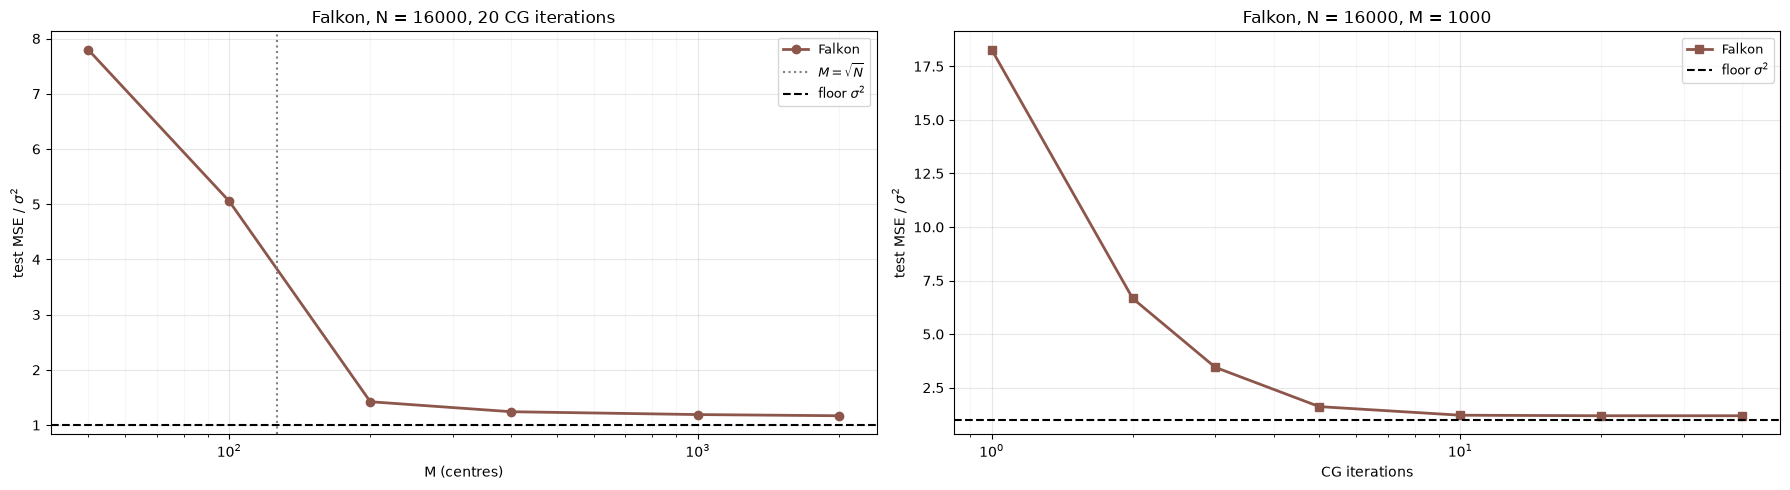

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].semilogx(M_values, falkon_M, "o-", color="C5", lw=2, label="Falkon")
axes[0].axvline(jnp.sqrt(n), color="grey", ls=":", lw=1.5, label=r"$M = \sqrt{N}$")
axes[0].set_xlabel("M (centres)")
axes[0].set_title(f"Falkon, N = {n}, 20 CG iterations")
axes[1].semilogx(iter_values, falkon_T, "s-", color="C5", lw=2, label="Falkon")
axes[1].set_xlabel("CG iterations")
axes[1].set_title(f"Falkon, N = {n}, M = 1000")
for ax in axes:
    ax.axhline(1.0, color="k", ls="--", lw=1.5, label=r"floor $\sigma^2$")
    ax.set_ylabel(r"test MSE / $\sigma^2$")
    ax.legend(fontsize=9)
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
plt.tight_layout()
plt.show()

The test error falls steeply up to $M = 200$ (7.80 at $M = 50$, 1.42 at $M = 200$) and slowly after: 1.24 at 400, 1.19 at 1000 and 1.17 at 2000. The theory asks for $M$ of order $\sqrt N \approx 126$; here the curve flattens at a few times that. Every fit used its full 20 iterations without reaching the $10^{-6}$ tolerance, but the right panel shows that prediction does not need it: the error is 1.62 after 5 iterations, 1.215 after 10, and 1.190 after 20, the same to three decimals as after 40. About 20 iterations suffice.

## EigenPro: epochs and damped eigendirections

EigenPro has no ridge, so the number of passes over the data is what stops it from interpolating the noise. At $N = 4000$ we train for 1 to 8 epochs with 20, 80 and 160 damped eigendirections ($q$, `n_components`), each from a fresh start.

In [17]:
n = 4000
X, y = X_all[:n], y_all[:n]
epoch_values = [1, 2, 4, 8]
q_values = [20, 80, 160]
eigenpro = {}
for q in q_values:
    eigenpro[q] = []
    for e in epoch_values:
        model = fit_jit(
            kl.EigenPro(
                kernel, epochs=e, batch_size=512, subsample_size=2000, n_components=q
            ),
            X,
            y,
            fit_key,
        )
        eigenpro[q].append(score(model.predict(X_test)))
    row = ", ".join(f"{s:.3f}" for s in eigenpro[q])
    print(f"q = {q:3d}: MSE/s2 by epoch {epoch_values} = {row}")

q =  20: MSE/s2 by epoch [1, 2, 4, 8] = 5.365, 3.832, 2.247, 1.618


q =  80: MSE/s2 by epoch [1, 2, 4, 8] = 1.532, 1.424, 1.414, 1.439


q = 160: MSE/s2 by epoch [1, 2, 4, 8] = 1.639, 1.349, 1.353, 1.367


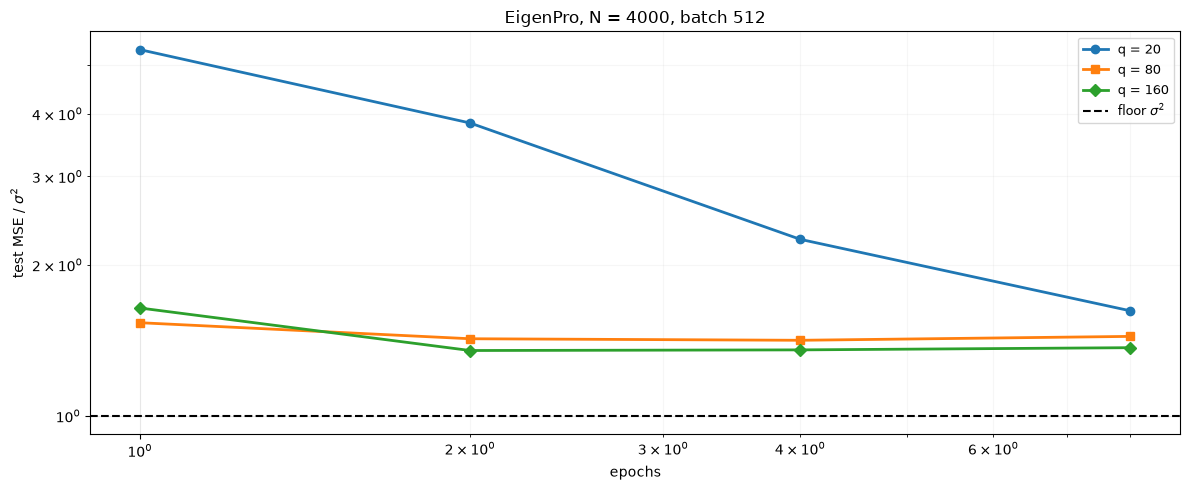

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
for q, marker in zip(q_values, ["o", "s", "D"], strict=True):
    ax.semilogx(epoch_values, eigenpro[q], marker=marker, lw=2, label=f"q = {q}")
ax.axhline(1.0, color="k", ls="--", lw=1.5, label=r"floor $\sigma^2$")
ax.set_xlabel("epochs")
ax.set_ylabel(r"test MSE / $\sigma^2$")
ax.set_yscale("log")
ax.set_title(f"EigenPro, N = {n}, batch 512")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
plt.tight_layout()
plt.show()

With only 20 damped directions EigenPro converges slowly: 5.37 after one epoch and still 1.62 after eight. With 80 or 160 it is near its best after one or two epochs (1.53 and 1.64 after one, 1.42 and 1.35 after two), and then stops improving or gets slightly worse (with $q = 80$: 1.414 after 4 epochs, 1.439 after 8), since there is no ridge to stop it from fitting the noise. Dense KRR at the same $N = 4000$ scored 1.293, so a few epochs of EigenPro land within about 4 to 10 percent of it. Damp enough directions (80 or more here) and stop after a few epochs.

## Choosing $\lambda$

Falkon's system $(K_{nm}^\top K_{nm} + \lambda N K_{mm})$ and KRR's $(K + \lambda N I)$ carry the same $N$ scaling, so it is natural to think in terms of the shift $\lambda N$. We sweep it over seven decades. For each value we record Falkon's test error at $N = 16\,000$ (with $M = 1000$ and its default 20 iterations), and the CG iterations that plain and RPCholesky-preconditioned CG need on the KRR system at $N = 2000$, with a budget of 3000.

In [19]:
shifts = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]
X_f, y_f = X_all[:16_000], y_all[:16_000]
X_c, y_c = X_all[:2000], y_all[:2000]
lam_rows = []
print(f"{'lambda N':>9} {'Falkon MSE/s2':>14} {'conv.':>6} {'CG':>5} {'PCG':>5}")
for shift in shifts:
    falkon = fit_jit(
        kl.Falkon(
            kernel, n_inducing=1000, regularization=shift / 16_000, implicit=False
        ),
        X_f,
        y_f,
        fit_key,
    )
    s = score(falkon.predict(X_test))
    plain = int(cg_steps(X_c, y_c, shift, "none", jax.random.PRNGKey(5)))
    pre = int(cg_steps(X_c, y_c, shift, "rpcholesky", jax.random.PRNGKey(5)))
    lam_rows.append((shift, s, bool(falkon.converged), plain, pre))
    print(f"{shift:>9.0e} {s:>14.3f} {bool(falkon.converged)!s:>6} {plain:>5} {pre:>5}")

 lambda N  Falkon MSE/s2  conv.    CG   PCG


    1e-05          2.419  False  3000   326


    1e-04          1.415  False  2330   109


    1e-03          1.151  False   682    36


    1e-02          1.190  False   224    13


    1e-01          1.263  False    80     7


    1e+00          2.388   True    31     5


    1e+01          6.187   True    15     3


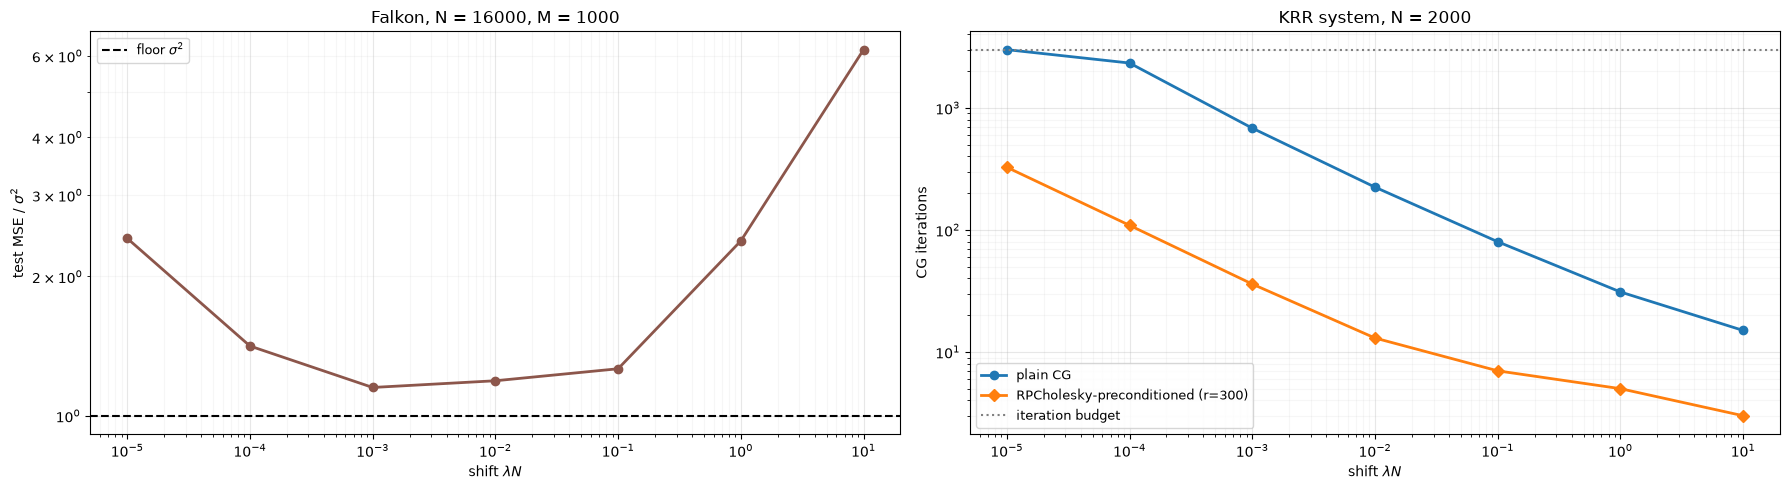

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].loglog(shifts, [r[1] for r in lam_rows], "o-", color="C5", lw=2)
axes[0].axhline(1.0, color="k", ls="--", lw=1.5, label=r"floor $\sigma^2$")
axes[0].set_ylabel(r"test MSE / $\sigma^2$")
axes[0].set_title("Falkon, N = 16000, M = 1000")
axes[0].legend(fontsize=9)
axes[1].loglog(shifts, [r[3] for r in lam_rows], "o-", lw=2, label="plain CG")
axes[1].loglog(
    shifts,
    [r[4] for r in lam_rows],
    "D-",
    lw=2,
    label=f"RPCholesky-preconditioned (r={R_PRECOND})",
)
axes[1].axhline(3000, color="grey", ls=":", lw=1.5, label="iteration budget")
axes[1].set_ylabel("CG iterations")
axes[1].set_title("KRR system, N = 2000")
axes[1].legend(fontsize=9)
for ax in axes:
    ax.set_xlabel(r"shift $\lambda N$")
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
plt.tight_layout()
plt.show()

Falkon's error is lowest at $\lambda N = 10^{-3}$ (1.151), close at $10^{-2}$ (1.190, the value used throughout) and $10^{-1}$ (1.263), and rises on both sides: 2.42 at $10^{-5}$, 2.39 at $1$ and 6.19 at $10$. Too large a ridge oversmooths; too small a one fits the noise. Falkon reached its tolerance within 20 iterations only for $\lambda N \ge 1$, but as the previous section showed, that is not what limits its accuracy.

For plain CG the price of a small ridge is iterations: 15 at $\lambda N = 10$, 224 at $10^{-2}$, 2330 at $10^{-4}$, and at $10^{-5}$ it used up its budget of 3000 without converging. The preconditioned solve needed 3 to 326 iterations over the same range, 5 to 21 times fewer wherever plain CG converged. Inside `KRR`, a `gx.CGSolver` that hits its `max_steps` raises an error rather than returning a partial answer, so a plain-CG fit at small $\lambda$ fails outright unless `max_steps` is raised. A $\lambda N$ between $10^{-3}$ and $10^{-2}$ is a sensible starting point for this problem; for a new problem, choose it on a validation set.

## Recommendations

What this notebook measured, for a smooth 8-dimensional target on the CPU above (the numbers will move with the problem and the hardware, the ordering less so):

| $N$ | Method | Settings that worked here |
|---|---|---|
| up to a few thousand | `KRR` (dense) | `regularization` with $\lambda N$ of $10^{-3}$ to $10^{-2}$, chosen on validation data |
| a few thousand, when the $N \times N$ matrix fits in memory and you want the exact KRR solution | `KRR(preconditioner="nystrom")` | `preconditioner_rank=300`; as fast as dense at $N = 4000$ (0.91 s against 0.98 s) |
| from a few thousand up | `Falkon` | `n_inducing` a few times $\sqrt N$ (400 to 1000 here), `max_iter=20`, $\lambda N$ of $10^{-3}$ to $10^{-2}$ |
| any, when speed matters more than the last few percent | ridge on `RandomFourierFeatures` | 512 frequencies (1024 features): the fastest fit from $N = 2000$ up, 3 to 4 percent behind Falkon |
| any, if you want no ridge | `EigenPro` | `n_components` of 80 or more, 2 to 4 epochs; the slowest method here |
| avoid | `KRR(solver=gx.CGSolver())` without a preconditioner | iterations grow with $N$ and explode as $\lambda$ shrinks |

With gaussx 0.6.1, prefer `"nystrom"` over `"rpcholesky"` for the `KRR` preconditioner: the two need the same number of CG iterations, but RPCholesky's preconditioner currently costs $r$ separate full matvecs to build, which is especially slow with `implicit=True`. We stopped dense and CG-based `KRR` at $N = 4000$, EigenPro at 8000, and Falkon and random features at 16 000 to keep the notebook within a five-minute budget on this machine; we did not extrapolate past those sizes.

The decision guide for choosing among kernellib's methods more broadly is tracked in [kernellib#88](https://github.com/jejjohnson/kernellib/issues/88).

In [21]:
elapsed = time.perf_counter() - notebook_start
print(f"Total notebook runtime: {elapsed / 60:.1f} min")
print("Load average (1, 5, 15 min): {:.1f}, {:.1f}, {:.1f}".format(*os.getloadavg()))

Total notebook runtime: 5.0 min
Load average (1, 5, 15 min): 18.5, 18.2, 20.3
